# Homework 1

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

## Packages

In [ ]:
#install.packages("fBasics")
#install.packages("tidyverse")
#install.packages("moments")

In [2]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(moments)
library(fBasics)
library(stabledist)

Warning message:
"package 'tidyverse' was built under R version 4.5.2"
Warning message:
"package 'tidyr' was built under R version 4.5.2"
Warning message:
"package 'readr' was built under R version 4.5.2"
Warning message:
"package 'purrr' was built under R version 4.5.2"
Warning message:
"package 'stringr' was built under R version 4.5.2"
Warning message:
"package 'forcats' was built under R version 4.5.2"
Warning message:
"package 'lubridate' was built under R version 4.5.2"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.5     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflic

## Problem 1

### Part 1

Import the data and store each data frame into a list of data frames. make sure there is a distinction between the data of each student in the group: that is done by adding the student code before each ticker

In [30]:
# 1. Get the full paths for all files inside the HA1 folder and its subfolders
target_folders <- c("33551440","70701808","73123255")
file_paths <- list.files(path = target_folders, full.names = TRUE, pattern = "\\.csv$")

# 2. Read all the files into a single list of data frames
list_of_dfs <- lapply(file_paths, read.csv)

# 3. Extract the folder names and ticker names to create the new labels
folder_names <- basename(dirname(file_paths))
ticker_names <- tools::file_path_sans_ext(basename(file_paths))

# 4. Combine them with an underscore and assign them as the names of the list items
names(list_of_dfs) <- paste(folder_names, ticker_names, sep = "_")

In [31]:
#inspecting the ticker names in the list
names(list_of_dfs)

[1] "33551440_AFL"  "33551440_ALGN" "33551440_C"    "33551440_CAT" 
 [5] "33551440_CZR"  "33551440_HIG"  "33551440_ORCL" "33551440_TMO" 
 [9] "33551440_TSCO" "33551440_WAT"  "70701808_AMCR" "70701808_AME" 
[13] "70701808_BA"   "70701808_EQT"  "70701808_KIM"  "70701808_KMI" 
[17] "70701808_LOW"  "70701808_MS"   "70701808_PCAR" "70701808_WAT" 
[21] "73123255_CSGP" "73123255_CTRA" "73123255_ES"   "73123255_MRK" 
[25] "73123255_NOC"  "73123255_ON"   "73123255_ORCL" "73123255_TFC"

In [32]:
lapply(list_of_dfs, colnames)

$`33551440_AFL`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_ALGN`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_C`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_CAT`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_CZR`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_HIG`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_ORCL`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_TMO`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_TSCO`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_WAT`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_AMCR`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_AME`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_BA`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_EQT`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_KIM`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_KMI`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_LOW`
[1] "Date"   "Klose"  "Open"   "High"   "Low"    "Volume"

$`70701808_MS`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_PCAR`
[1] "Date"   "Klose"  "Open"   "High"   "Low"    "Volume"

$`70701808_WAT`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_CSGP`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_CTRA`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_ES`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_MRK`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_NOC`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_ON`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_ORCL`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_TFC`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

**data celaning:** Upon inspection of the column names, we find that some dataframes contain the column Klose instead of Close. We rename such columns using lapply.

In [33]:
list_of_dfs <- lapply(list_of_dfs, function(df) {
  names(df)[names(df) == "Klose"] <- "Close"
  df
})

We check if it worked

In [34]:
lapply(list_of_dfs, colnames)

$`33551440_AFL`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_ALGN`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_C`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_CAT`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_CZR`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_HIG`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_ORCL`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_TMO`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_TSCO`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`33551440_WAT`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_AMCR`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_AME`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_BA`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_EQT`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_KIM`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_KMI`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_LOW`
[1] "Date"   "Close"  "Open"   "High"   "Low"    "Volume"

$`70701808_MS`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`70701808_PCAR`
[1] "Date"   "Close"  "Open"   "High"   "Low"    "Volume"

$`70701808_WAT`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_CSGP`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_CTRA`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_ES`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_MRK`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_NOC`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_ON`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_ORCL`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$`73123255_TFC`
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

We move on to further inspection

In [35]:
lapply(list_of_dfs, nrow)
lapply(list_of_dfs, head)

$`33551440_AFL`
[1] 1754

$`33551440_ALGN`
[1] 1759

$`33551440_C`
[1] 1759

$`33551440_CAT`
[1] 1759

$`33551440_CZR`
[1] 1759

$`33551440_HIG`
[1] 1759

$`33551440_ORCL`
[1] 1756

$`33551440_TMO`
[1] 1759

$`33551440_TSCO`
[1] 1759

$`33551440_WAT`
[1] 1759

$`70701808_AMCR`
[1] 1759

$`70701808_AME`
[1] 1759

$`70701808_BA`
[1] 1757

$`70701808_EQT`
[1] 1759

$`70701808_KIM`
[1] 1756

$`70701808_KMI`
[1] 1756

$`70701808_LOW`
[1] 1758

$`70701808_MS`
[1] 1759

$`70701808_PCAR`
[1] 1759

$`70701808_WAT`
[1] 1759

$`73123255_CSGP`
[1] 1756

$`73123255_CTRA`
[1] 1757

$`73123255_ES`
[1] 1759

$`73123255_MRK`
[1] 1759

$`73123255_NOC`
[1] 1759

$`73123255_ON`
[1] 1757

$`73123255_ORCL`
[1] 1758

$`73123255_TFC`
[1] 1759

,Date,Open,High,Low,Close,Volume,Dividends,Stock.Splits
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,2019-01-02,37.626,38.462,37.576,38.411,4022100,0,0
2,2019-01-03,38.284,38.462,37.365,37.441,4239700,0,0
3,2019-01-04,37.989,38.183,37.711,37.905,4761500,0,0
4,2019-01-07,37.879,38.495,37.711,38.107,3414400,0,0
5,2019-01-08,38.403,38.538,37.829,38.225,3017000,0,0
6,2019-01-09,38.386,38.647,38.099,38.141,4501100,0,0
,Date,Open,High,Low,Close,Volume,Dividends,Stock.Splits
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>
1,2019-01-02,205.32,207.16,200.54,202.12,1126800,0,0


We can already suspect missing values in some cases and that the times series begin on 2nd January 2019. Furthermore some series will have missing dates compared to others as the dimensions of some are smaller by a fine margin

**data cleaning:** Lets formate the Date columns so they are all in the same format

In [37]:
list_of_dfs <- lapply(list_of_dfs, function(df) {
  # 1. Identify which columns have "Date" in the name
  date_cols <- grep("Date", names(df), ignore.case = TRUE)
  
  # 2. Convert only those columns to character yyyy-mm-dd
  df[date_cols] <- lapply(df[date_cols], function(x) {
    format(as.Date(x), "%Y-%m-%d")
  })
  
  return(df)
})

### Task 1

For each time series we **discard everything other than "Date" and "Close"** in terms of variables (columns)

In [38]:
trimmed_list <- lapply(list_of_dfs, function(df) {
  df[, c("Date", "Close")]
})

check the results and correctness

In [39]:
lapply(trimmed_list, head)

lapply(trimmed_list, nrow)

,Date,Close
,<chr>,<dbl>
1,2019-01-02,38.411
2,2019-01-03,37.441
3,2019-01-04,37.905
4,2019-01-07,38.107
5,2019-01-08,38.225
6,2019-01-09,38.141
,Date,Close
,<chr>,<chr>
1,2019-01-02,202.12


$`33551440_AFL`
[1] 1754

$`33551440_ALGN`
[1] 1759

$`33551440_C`
[1] 1759

$`33551440_CAT`
[1] 1759

$`33551440_CZR`
[1] 1759

$`33551440_HIG`
[1] 1759

$`33551440_ORCL`
[1] 1756

$`33551440_TMO`
[1] 1759

$`33551440_TSCO`
[1] 1759

$`33551440_WAT`
[1] 1759

$`70701808_AMCR`
[1] 1759

$`70701808_AME`
[1] 1759

$`70701808_BA`
[1] 1757

$`70701808_EQT`
[1] 1759

$`70701808_KIM`
[1] 1756

$`70701808_KMI`
[1] 1756

$`70701808_LOW`
[1] 1758

$`70701808_MS`
[1] 1759

$`70701808_PCAR`
[1] 1759

$`70701808_WAT`
[1] 1759

$`73123255_CSGP`
[1] 1756

$`73123255_CTRA`
[1] 1757

$`73123255_ES`
[1] 1759

$`73123255_MRK`
[1] 1759

$`73123255_NOC`
[1] 1759

$`73123255_ON`
[1] 1757

$`73123255_ORCL`
[1] 1758

$`73123255_TFC`
[1] 1759

**data cleaning:** Some Close columns are stored as characters, let us look into that first and see what causes that. We are checking rows which are not recognized by the as.numeric function:

In [40]:
filtered_results <- Filter(length, lapply(trimmed_list, function(df) {
  
  broken_rows <- suppressWarnings(is.na(as.numeric(df$Close)))
  
  actual_typos <- broken_rows & !is.na(df$Close)
  
  unique(df$Close[actual_typos])
}))

filtered_results

$`33551440_ALGN`
[1] "whoops"

$`33551440_C`
[1] "whoops"

$`33551440_CZR`
[1] "whoops"

$`70701808_BA`
[1] "whoops"

$`70701808_KIM`
[1] "whoops"

$`73123255_CSGP`
[1] "whoops"

We found the trickery in the data, let us treat these as NAs from now on

In [55]:
#convert all Close to numeric, the whoops will be turned into NA
numeric_list <- lapply(trimmed_list, function(df) {
  df$Close <- suppressWarnings(as.numeric(df$Close))
  return(df)
})

Now we rerun the numeric check to see if the whoops rows were correctly transformed

In [56]:
filtered_results_2 <- Filter(length, lapply(numeric_list, function(df) {
  
  broken_rows <- suppressWarnings(is.na(as.numeric(df$Close)))
  
  actual_typos <- broken_rows & !is.na(df$Close)
  
  unique(df$Close[actual_typos])
}))

filtered_results_2

named list()

**data cleaning:** The result is an empty list, so the transformation worked. We move on to detecting NA values

In [57]:
#locate each NA and print the surrounding rows
for (stock_name in names(numeric_list)) {
  
  df <- numeric_list[[stock_name]]
  
  na_rows <- which(is.na(df$Close))
  
  if (length(na_rows) > 0) {
    cat("\n=== NAs found in:", stock_name, "===\n")
    
    for (i in na_rows) {
      rows_to_print <- max(1, i - 2) : min(nrow(df), i + 2)
      
      cat("--> NA located at Row", i, ":\n")
      print(df[rows_to_print, ])
      cat("\n")
    }
  }
}


=== NAs found in: 33551440_ALGN ===
--> NA located at Row 224 :
          Date  Close
222 2019-11-15 263.92
223 2019-11-18 268.51
224 2019-11-19     NA
225 2019-11-20 268.77
226 2019-11-21 272.14


=== NAs found in: 33551440_C ===
--> NA located at Row 793 :
          Date  Close
791 2022-02-18 55.436
792 2022-02-22 55.220
793 2022-02-23     NA
794 2022-02-24 52.437
795 2022-02-25 53.569


=== NAs found in: 33551440_CZR ===
--> NA located at Row 1145 :
           Date Close
1143 2023-07-18 56.35
1144 2023-07-19 57.68
1145 2023-07-20    NA
1146 2023-07-21 57.73
1147 2023-07-24 57.77


=== NAs found in: 33551440_ORCL ===
--> NA located at Row 1 :
        Date    Close
1 2019-01-02       NA
2 2019-01-03 40.25007
3 2019-01-04 41.94768


=== NAs found in: 33551440_TMO ===
--> NA located at Row 1 :
        Date    Close
1 2019-01-02       NA
2 2019-01-03 208.2297
3 2019-01-04 217.4348


=== NAs found in: 33551440_TSCO ===
--> NA located at Row 1 :
        Date    Close
1 2019-01-02       NA

Most of the tickers have at least one NA, but the amount of NAs is minimal compared to the amount of observations. Therefore we have opted to keep NAs as they are and will not delete the whole rows for now as it might be useful further along.

The data cleaning is almost done, lets check why are some data frames shorter than others. All start at the same date so lets check the ending dates for all the data frames

In [58]:
ending_dates <- sapply(numeric_list, function(df) {
  tail(df$Date, 1)
})

print(ending_dates)

 33551440_AFL 33551440_ALGN    33551440_C  33551440_CAT  33551440_CZR 
 "2025-12-30"  "2025-12-30"  "2025-12-30"  "2025-12-30"  "2025-12-30" 
 33551440_HIG 33551440_ORCL  33551440_TMO 33551440_TSCO  33551440_WAT 
 "2025-12-30"  "2025-12-30"  "2025-12-30"  "2025-12-30"  "2025-12-30" 
70701808_AMCR  70701808_AME   70701808_BA  70701808_EQT  70701808_KIM 
 "2025-12-30"  "2025-12-30"  "2025-12-30"  "2025-12-30"  "2025-12-30" 
 70701808_KMI  70701808_LOW   70701808_MS 70701808_PCAR  70701808_WAT 
 "2025-12-30"  "2025-12-30"  "2025-12-30"  "2025-12-30"  "2025-12-30" 
73123255_CSGP 73123255_CTRA   73123255_ES  73123255_MRK  73123255_NOC 
 "2025-12-30"  "2025-12-30"  "2025-12-30"  "2025-12-30"  "2025-12-30" 
  73123255_ON 73123255_ORCL  73123255_TFC 
 "2025-12-30"  "2025-12-30"  "2025-12-30" 


**data cleaning:** the stocks data start and end at the same date so the problem is somewhere inside, lets look into that by comparing all the avaible dates to each of the stock

In [59]:
all_dates <- unlist(lapply(numeric_list, function(df) df$Date))

# 2. Extract only the unique dates to build our true Master Calendar, and sort them
true_master_calendar <- sort(unique(all_dates))

cat("Total unique dates across ALL stocks:", length(true_master_calendar), "\n")

# 3. Loop through and compare each stock to the true Master Calendar
for (stock_name in names(numeric_list)) {
  
  stock_dates <- numeric_list[[stock_name]]$Date
  
  missing_dates <- setdiff(true_master_calendar, stock_dates)
  
  if (length(missing_dates) > 0) {
    cat("\n=== Missing dates in:", stock_name, "===\n")
    print(missing_dates)
  }
}

Total unique dates across ALL stocks: 1759 

=== Missing dates in: 33551440_AFL ===
[1] "2020-03-10" "2020-08-07" "2023-05-26" "2023-11-28" "2024-02-23"

=== Missing dates in: 33551440_ORCL ===
[1] "2021-09-17" "2025-03-07" "2025-11-13"

=== Missing dates in: 70701808_BA ===
[1] "2020-02-11" "2023-08-01"

=== Missing dates in: 70701808_KIM ===
[1] "2020-04-01" "2020-11-25" "2025-12-08"

=== Missing dates in: 70701808_KMI ===
[1] "2019-11-13" "2021-03-19" "2023-03-03"

=== Missing dates in: 70701808_LOW ===
[1] "2022-02-11"

=== Missing dates in: 73123255_CSGP ===
[1] "2019-05-07" "2022-04-13" "2022-12-15"

=== Missing dates in: 73123255_CTRA ===
[1] "2021-06-30" "2024-08-20"

=== Missing dates in: 73123255_ON ===
[1] "2024-10-01" "2025-12-16"

=== Missing dates in: 73123255_ORCL ===
[1] "2024-05-09"


Some dates for these stocks are missing, we did not find a valuable reason for it. We keep the time series as it is for now but we will keep it in mind for later processes

**data cleaning:** Lastly we need to check if there are Dates duplicates

In [60]:
for (ticker in names(numeric_list)) {
  
  # Find dates that appear more than once
  duplicate_dates <- numeric_list[[ticker]]$Date[duplicated(numeric_list[[ticker]]$Date)]
  
  # Only print if duplicates actually exist
  if (length(duplicate_dates) > 0) {
    cat("Ticker:", ticker, "\n")
    print(unique(duplicate_dates))
    cat("\n")
  }
}

No dates duplicates have been found

**now we add the returns and log returns**

In [75]:
returns_list <- lapply(numeric_list, function(df) {
  df %>%
    mutate(Close = as.numeric(Close)) %>%
    mutate(
      rets_simple = (Close / lag(Close)) - 1,
      rets = log(Close / lag(Close))
    )
})

In [76]:
lapply(returns_list, head)

,Date,Close,rets_simple,rets
,<chr>,<dbl>,<dbl>,<dbl>
1,2019-01-02,38.411,NA,NA
2,2019-01-03,37.441,-0.025253183,-0.025577516
3,2019-01-04,37.905,0.012392831,0.012316669
4,2019-01-07,38.107,0.005329112,0.005314963
5,2019-01-08,38.225,0.003096544,0.003091760
6,2019-01-09,38.141,-0.002197515,-0.002199933
,Date,Close,rets_simple,rets
,<chr>,<dbl>,<dbl>,<dbl>
1,2019-01-02,202.12,NA,NA


**Plotting the returns** and since ggplot2 cannot work with the list of data frames, we will bind the into onle long data frame

Warning message:
"Removed 35 rows containing missing values or values outside the scale range (`geom_line()`)."


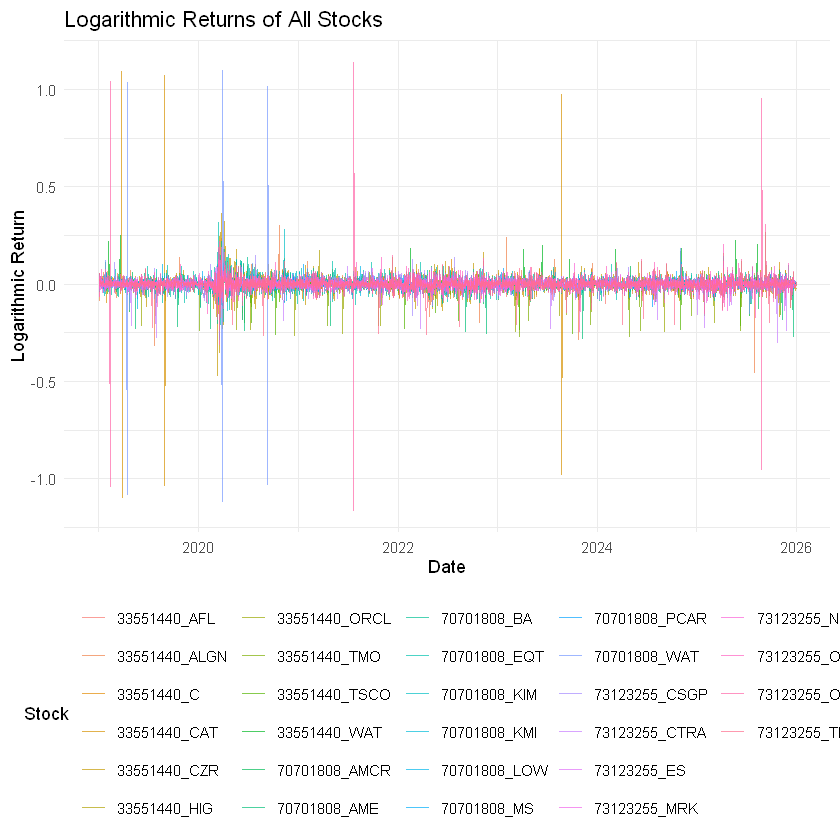

In [77]:
combined_returns0 <- bind_rows(returns_list, .id = "Ticker")

# 2. Make sure R knows the Date column represents actual dates (not text)
combined_returns0 <- combined_returns0 %>%
  mutate(Date = as.Date(Date))

ggplot(combined_returns0, aes(x = Date, y = rets, color = Ticker)) +
  geom_line(alpha = 0.7, linewidth = 0.3) + 
  theme_minimal() +
  labs(
    title = "Logarithmic Returns of All Stocks",
    x = "Date",
    y = "Logarithmic Return",
    color = "Stock"
  ) +
  theme(legend.position = "bottom")

The extreme logarithmic returns in some cases suggest at most roughly 170% daily stock price increase, in negative cases abouyt 70% stock price daily decrease. Such values are very unlikely. Furthermore a returns spike in one direction is followed by a spike in the other direction (seen in the chart). The following code inspects how the data looks around these spikes

In [78]:
# Loop through each stock in your list
for (stock_name in names(returns_list)) {
  
  df <- returns_list[[stock_name]]
  
  spike_rows <- which(abs(df$rets) > 0.4)
  
  # If we found any spikes, print them out
  if (length(spike_rows) > 0) {
    cat("\n=== Spikes found in:", stock_name, "===\n")
    
    for (row_idx in spike_rows) {
      # Calculate the window (ensuring we don't go below row 1 or past the end)
      start_row <- max(1, row_idx - 2)
      end_row <- min(nrow(df), row_idx + 2)
      
      # Print the 5-row window
      print(df[start_row:end_row, ])
      cat("--------------------\n")
    }
  }
}


=== Spikes found in: 33551440_ALGN ===
           Date  Close  rets_simple         rets
1652 2025-07-29 205.81 -0.006660553 -0.006682834
1653 2025-07-30 203.57 -0.010883825 -0.010943487
1654 2025-07-31 129.01 -0.366262219 -0.456120005
1655 2025-08-01 136.52  0.058212542  0.056581203
1656 2025-08-04 137.77  0.009156168  0.009114504
--------------------

=== Spikes found in: 33551440_CAT ===
         Date    Close  rets_simple         rets
56 2019-03-22 111.8470 -0.032004847 -0.032528199
57 2019-03-25 113.2350  0.012409810  0.012333439
58 2019-03-26 338.1927  1.986644728  1.094150593
59 2019-03-27 113.0800 -0.665634431 -1.095520365
60 2019-03-28 114.0880  0.008914043  0.008874548
--------------------
         Date    Close  rets_simple         rets
57 2019-03-25 113.2350  0.012409810  0.012333439
58 2019-03-26 338.1927  1.986644728  1.094150593
59 2019-03-27 113.0800 -0.665634431 -1.095520365
60 2019-03-28 114.0880  0.008914043  0.008874548
61 2019-03-29 116.7770  0.023569525  0.0232960

**data cleaning:** We will treat values with **logarithmic returns that are over 0.9 (abs) as NAs**, data shows that it is a consequence of a measurement error or error in the data 

In [79]:
for (ticker in names(returns_list)) {
  
  # Find rows where rets is strictly greater than 0.9 or less than -0.9
  bad_rows <- which(returns_list[[ticker]]$rets > 0.9 | returns_list[[ticker]]$rets < -0.9)
  
  # If any such rows exist, replace Close, rets, and rets_simple with NA
  if (length(bad_rows) > 0) {
    returns_list[[ticker]]$Close[bad_rows] <- NA
    returns_list[[ticker]]$rets[bad_rows] <- NA
    returns_list[[ticker]]$rets_simple[bad_rows] <- NA
  }
}

**recompute the rets and rets_simple**

In [80]:
returns_list2 <- lapply(returns_list, function(df) {
  df %>%
    mutate(Close = as.numeric(Close)) %>%
    mutate(
      rets_simple = (Close / lag(Close)) - 1,
      rets = log(Close / lag(Close))
    )
})

**plotting cleaned returns from outliers**

Warning message:
"Removed 35 rows containing missing values or values outside the scale range (`geom_line()`)."


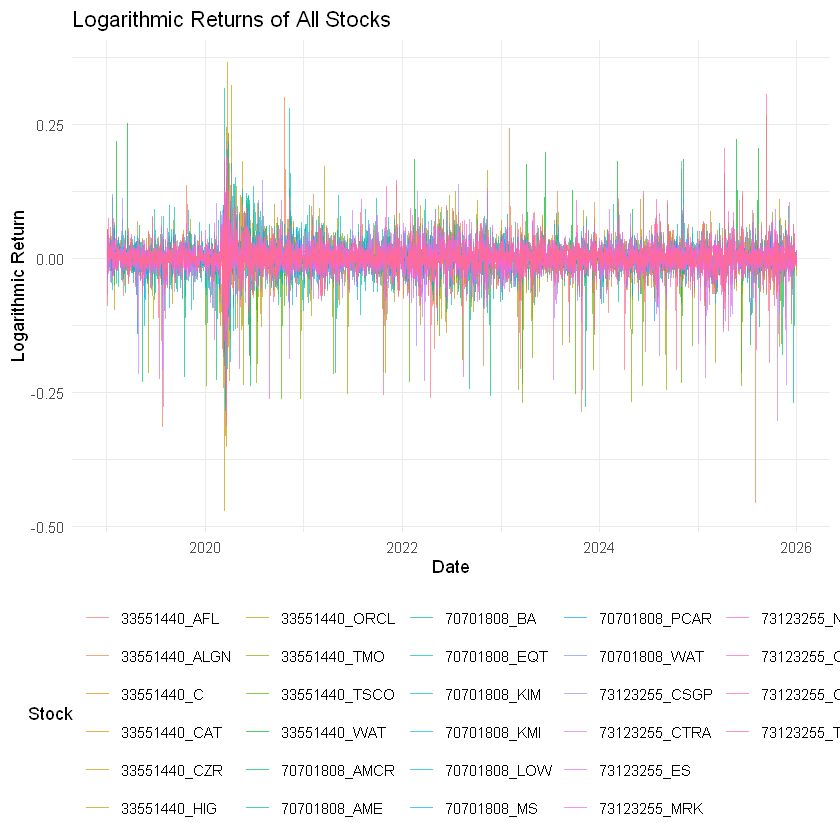

In [81]:
combined_returns <- bind_rows(returns_list2, .id = "Ticker")

# 2. Make sure R knows the Date column represents actual dates (not text)
combined_returns <- combined_returns %>%
  mutate(Date = as.Date(Date))

ggplot(combined_returns, aes(x = Date, y = rets, color = Ticker)) +
  geom_line(alpha = 0.7, linewidth = 0.3) + 
  theme_minimal() +
  labs(
    title = "Logarithmic Returns of All Stocks",
    x = "Date",
    y = "Logarithmic Return",
    color = "Stock"
  ) +
  theme(legend.position = "bottom")

Now the values look more like we would expect.

lets now **compute all the descriptive statistics** that are needed to get an overview of the data

In [83]:
summary_stats <- combined_returns %>%
  group_by(Ticker) %>%
  filter(!is.na(rets)) %>%
  summarise(
    Mean = mean(rets),
    Std_Dev = sd(rets),
    Minimum = min(rets),
    Maximum = max(rets),
    Skewness = skewness(rets),
    Kurtosis = kurtosis(rets)
  )

print(summary_stats, n = Inf)

# A tibble: 28 × 7
   Ticker             Mean Std_Dev Minimum Maximum Skewness Kurtosis
   <chr>             <dbl>   <dbl>   <dbl>   <dbl>    <dbl>    <dbl>
 1 33551440_AFL   0.000601  0.0181  -0.179  0.233   -0.263     33.5 
 2 33551440_ALGN -0.000140  0.0340  -0.456  0.300   -1.66      32.3 
 3 33551440_C     0.000616  0.0230  -0.214  0.165   -0.545     13.3 
 4 33551440_CAT   0.000937  0.0200  -0.154  0.110   -0.260      5.19
 5 33551440_CZR  -0.000273  0.0427  -0.470  0.366   -0.966     20.3 
 6 33551440_HIG   0.000749  0.0204  -0.238  0.244   -0.505     37.8 
 7 33551440_ORCL -0.000658  0.0283  -0.263  0.268   -2.58      31.6 
 8 33551440_TMO  -0.000818  0.0244  -0.270  0.0949  -4.51      42.8 
 9 33551440_TSCO -0.000673  0.0248  -0.261  0.0964  -4.24      36.3 
10 33551440_WAT   0.00136   0.0252  -0.161  0.252    2.63      24.8 
11 70701808_AMCR  0.000114  0.0175  -0.176  0.151   -0.756     17.5 
12 70701808_AME  -0.000842  0.0244  -0.277  0.144   -5.63      54.7 
13 70701808_BA 

Based on the descriptive statistics, the mean logarithmic returns across all time series are appropriately close to zero, with standard deviations reflecting typical daily equity volatility (ranging from roughly 1.5% to 4.2%). However, the higher-order moments and extreme values strongly indicate lingering data issues. Almost all stocks exhibit extreme leptokurtosis (fat tails), with kurtosis values far exceeding the normal distribution baseline of 3 (e.g., AME at 54.7 and TMO at 42.8). Furthermore, several series display highly suspicious minimum and maximum daily log returns, such as CZR's -0.470 (a ~37% single-day drop) and ALGN's -0.456. Coupled with pronounced negative skewness across the board.

The AME is the ticker with highest observer kurtosis and skeweness. With all tickers having similar mean and variance we select this as the **time series most strongly departing from normality**

In [91]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 300)

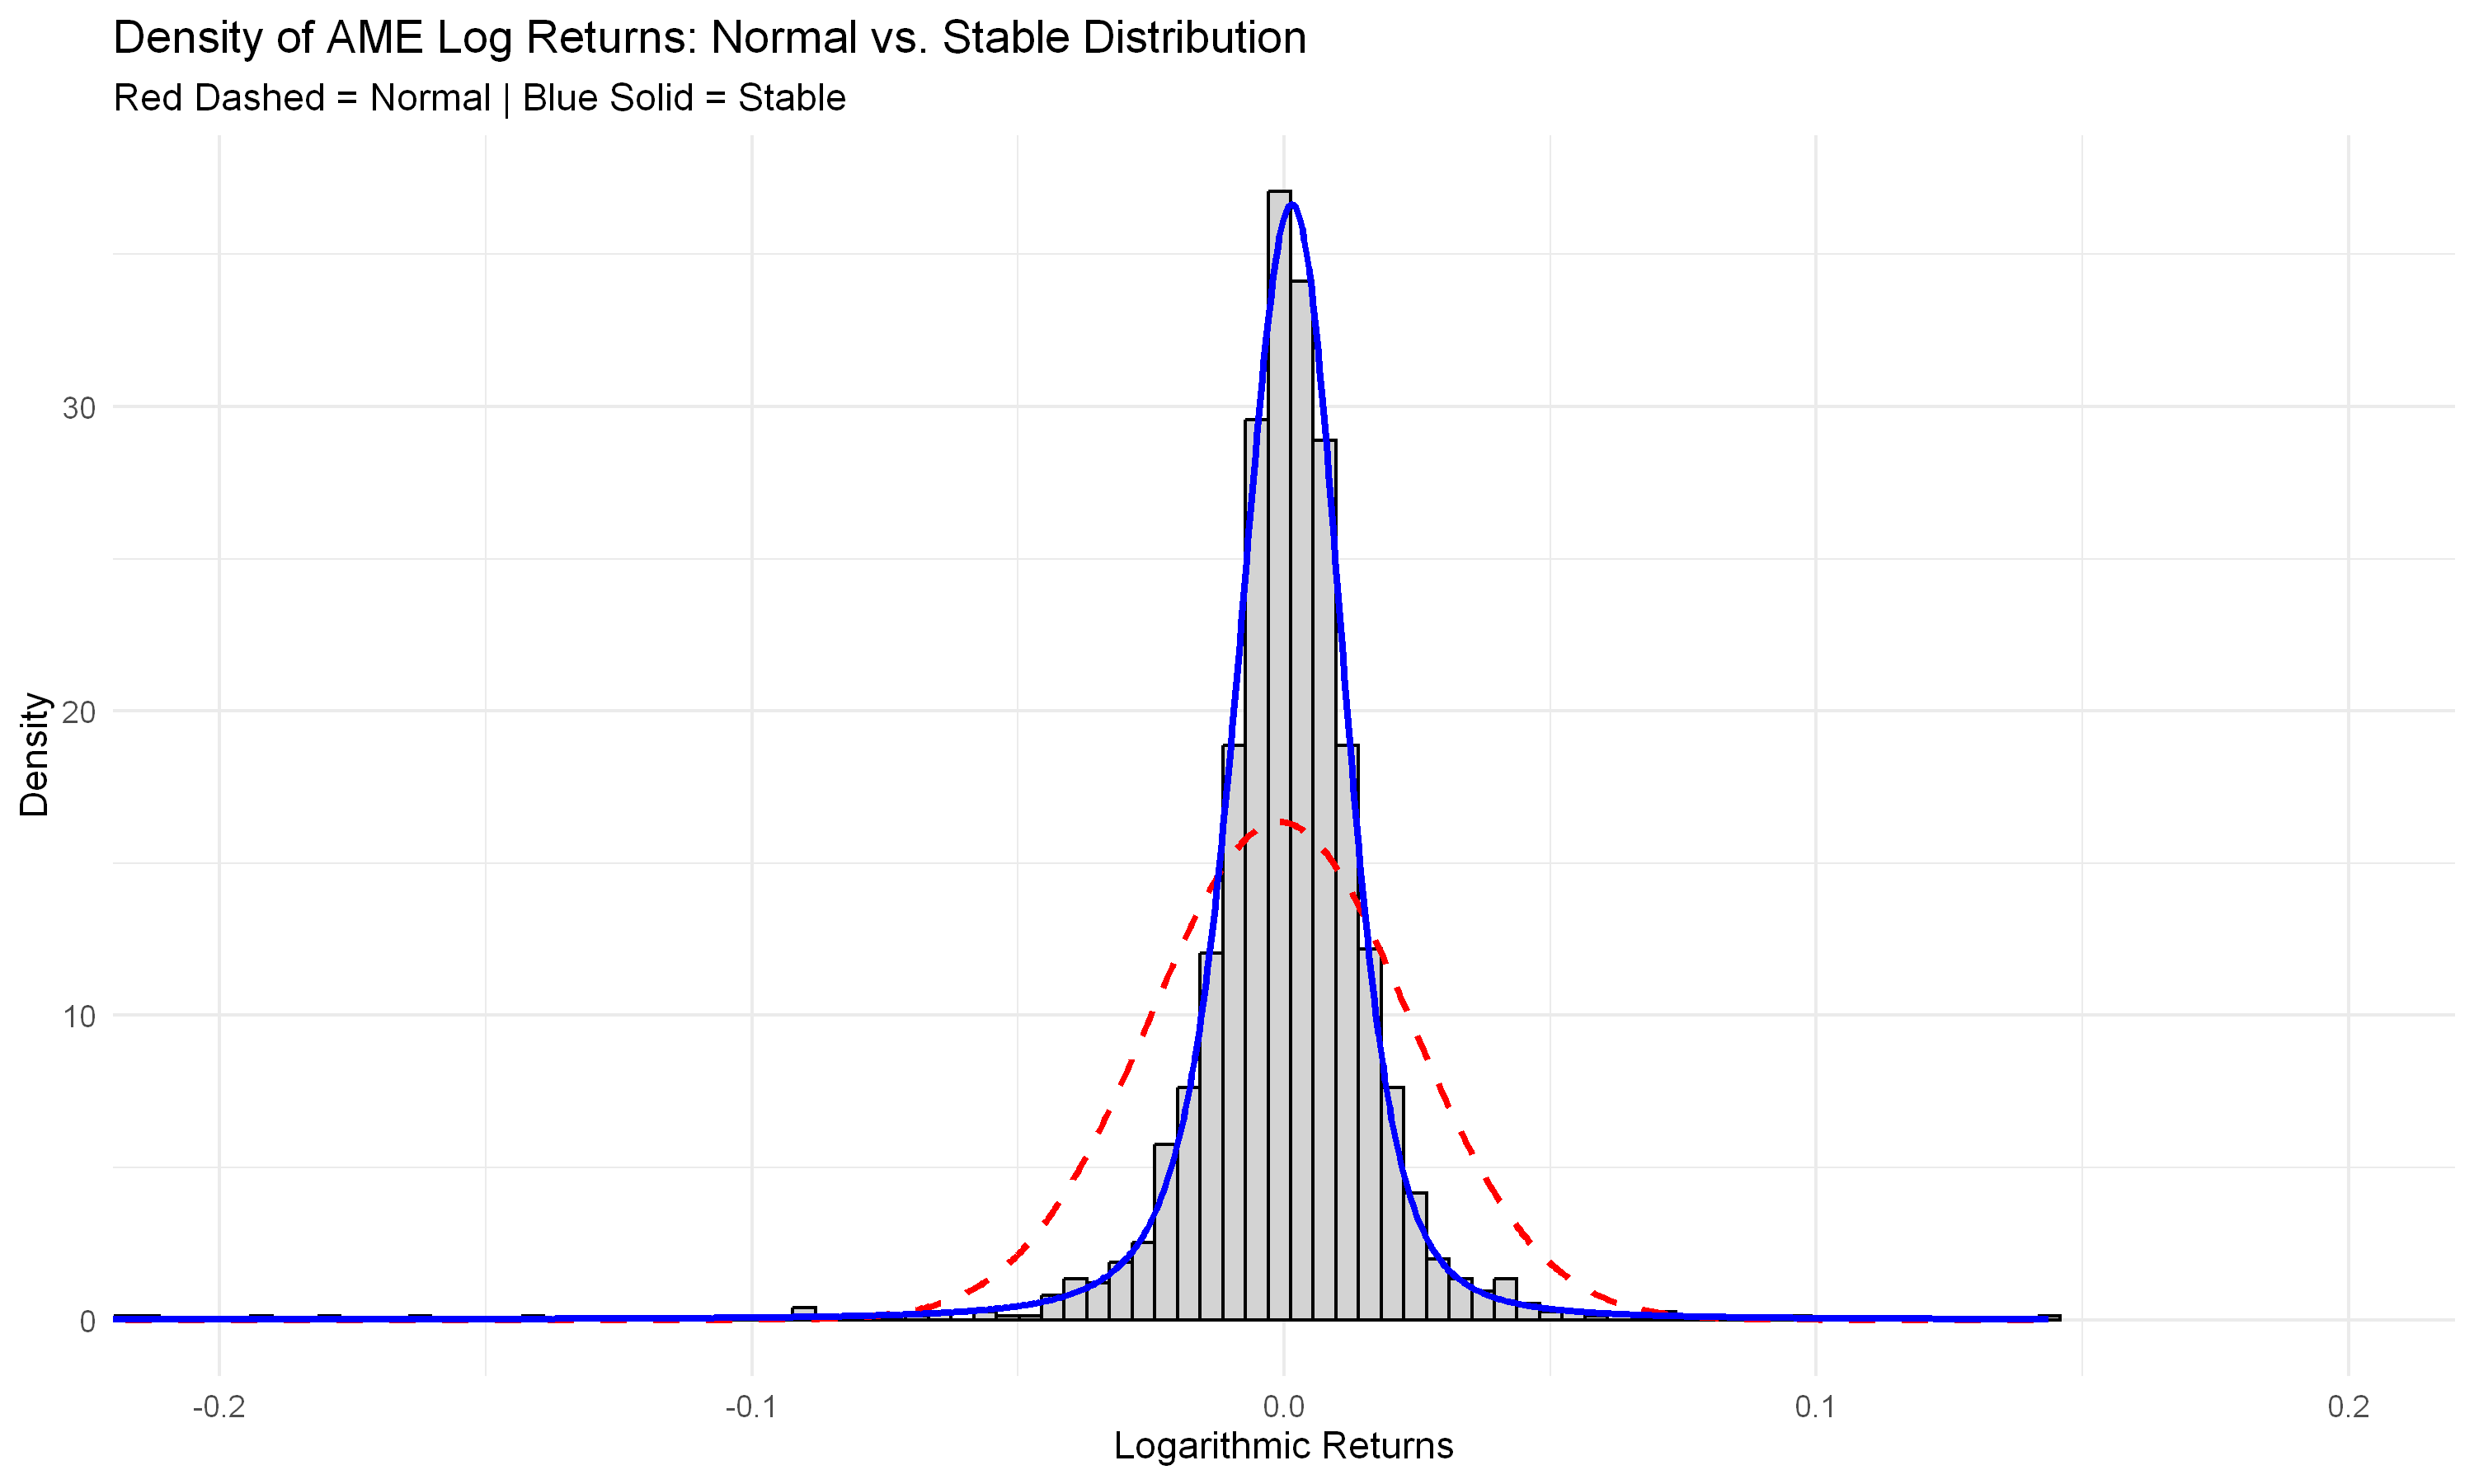

In [92]:
AME_rets <- combined_returns %>%
  filter(Ticker == "70701808_AME" & !is.na(rets)) %>%
  pull(rets)

mu <- mean(AME_rets)
sigma <- sd(AME_rets)

stable_fit <- stableFit(AME_rets, doplot = FALSE)

alpha_fit <- stable_fit@fit$estimate["alpha"]
beta_fit  <- stable_fit@fit$estimate["beta"]
gamma_fit <- stable_fit@fit$estimate["gamma"]
delta_fit <- stable_fit@fit$estimate["delta"]

ggplot(data.frame(rets = AME_rets), aes(x = rets)) +
  geom_histogram(aes(y = after_stat(density)), bins = 100, fill = "lightgray", color = "black") +
  
  stat_function(fun = dnorm, args = list(mean = mu, sd = sigma), 
                color = "red", linewidth = 1, linetype = "dashed",n = 1000) +
  
  stat_function(fun = dstable, 
                args = list(alpha = alpha_fit, beta = beta_fit, 
                            gamma = gamma_fit, delta = delta_fit), 
                color = "blue", linewidth = 1,n = 1000) +
  
  theme_minimal() +
  coord_cartesian(xlim = c(-0.2, 0.2)) + # Zoom in to see the peak clearly 
  labs(
    title = "Density of AME Log Returns: Normal vs. Stable Distribution",
    subtitle = "Red Dashed = Normal | Blue Solid = Stable",
    x = "Logarithmic Returns",
    y = "Density"
  )

### PART 2

put the time series into same data frame and keep only the dates where all the tickers have values

In [46]:
wide_returns <- combined_returns %>%
  select(Date, Ticker, rets) %>%
  pivot_wider(names_from = Ticker, values_from = rets)

clean_wide_returns <- wide_returns %>%
  drop_na()

and then compute the cross sectional mean logarithmic return for each date

In [47]:
mean_series <- clean_wide_returns %>%
  mutate(cross_sectional_mean = rowMeans(select(., -Date))) %>%
  select(Date, cross_sectional_mean)


head(mean_series)

Date,cross_sectional_mean
<date>,<dbl>
2019-01-03,-0.020191547
2019-01-04,0.033173535
2019-01-07,0.014497003
2019-01-08,0.010578820
2019-01-09,0.011487797
2019-01-10,0.009039159


the only couple deleted values are because of the missing dates in some of the time series (descussed before). However as the number of missing dates is well below 10, it is in line with standard practice to just ommit these dates for all tickers

In [48]:
mean_returns_vec <- mean_series$cross_sectional_mean

mean_stable_fit <- stableFit(mean_returns_vec, doplot = FALSE)

mean_params <- mean_stable_fit@fit$estimate
print("Parameters for Cross-Sectional Mean Returns:")
print(mean_params)

[1] "Parameters for Cross-Sectional Mean Returns:"
        alpha          beta         gamma         delta 
 1.5950000000 -0.1670000000  0.0081994140  0.0006782053 


Warning message:
"The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead."


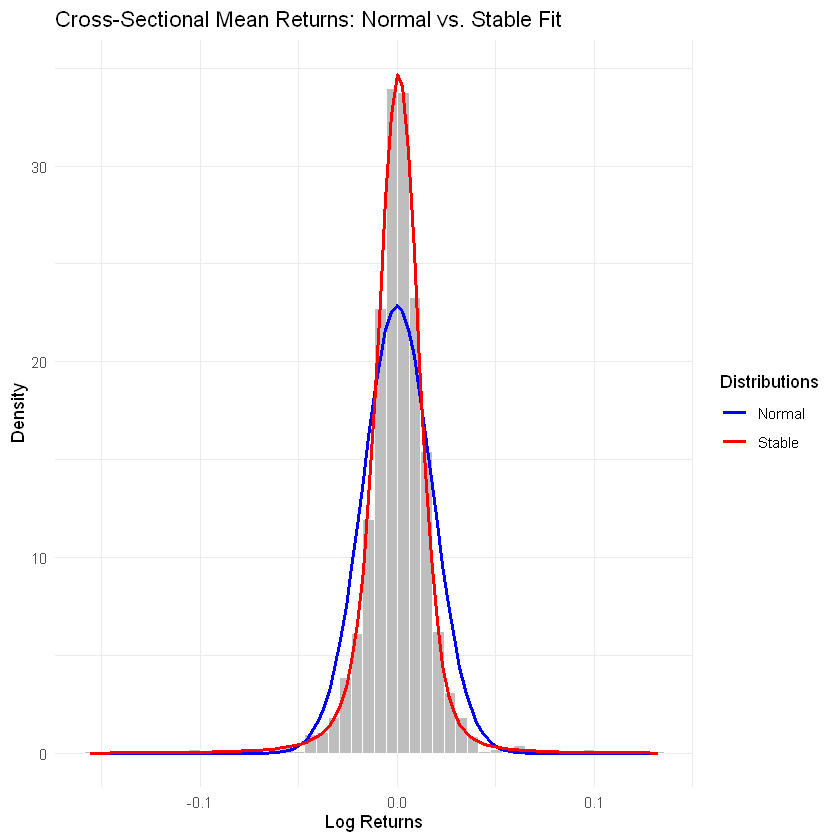

In [49]:
mu <- mean(mean_series$cross_sectional_mean, na.rm = TRUE)
sigma <- sd(mean_series$cross_sectional_mean, na.rm = TRUE)

stable_fit <- stableFit(mean_series$cross_sectional_mean, doplot = FALSE)
s_params <- stable_fit@fit$estimate

ggplot(mean_series, aes(x = cross_sectional_mean)) +
  geom_histogram(aes(y = ..density..), bins = 50, fill = "gray", color = "white") +
  
  stat_function(fun = dnorm, 
                args = list(mean = mu, sd = sigma), 
                aes(color = "Normal"), size = 1) +
  
  stat_function(fun = dstable, 
                args = list(alpha = s_params[1], beta = s_params[2], 
                            gamma = s_params[3], delta = s_params[4]), 
                aes(color = "Stable"), size = 1) +
  
  scale_color_manual(name = "Distributions", 
                     values = c("Normal" = "blue", "Stable" = "red")) +
  labs(title = "Cross-Sectional Mean Returns: Normal vs. Stable Fit",
       x = "Log Returns",
       y = "Density") +
  theme_minimal()

In [50]:
mean_stats <- mean_series %>%
  summarise(
    Mean = mean(cross_sectional_mean, na.rm = TRUE),
    Std_Dev = sd(cross_sectional_mean, na.rm = TRUE),
    Minimum = min(cross_sectional_mean, na.rm = TRUE),
    Maximum = max(cross_sectional_mean, na.rm = TRUE),
    Skewness = skewness(cross_sectional_mean, na.rm = TRUE),
    Kurtosis = kurtosis(cross_sectional_mean, na.rm = TRUE)
  )

print(mean_stats)

# A tibble: 1 × 6
      Mean Std_Dev Minimum Maximum Skewness Kurtosis
     <dbl>   <dbl>   <dbl>   <dbl>    <dbl>    <dbl>
1 0.000137  0.0174  -0.156   0.133   -0.562     16.0


## Problem 2

In [64]:
options(repr.plot.width = 16, repr.plot.height = 5)

In [54]:
#set seed so the results can be replicated
set.seed(433)

define our simulation parameters

In [57]:
N <- 100    # Length of the time series
sims <- 500   #number of realizations

define high and low variance

In [58]:
low_var_matrix <- replicate(sims, cumsum(c(0, rnorm(N, sd = 1))))

high_var_matrix <- replicate(sims, cumsum(c(0, rnorm(N, sd = 4))))

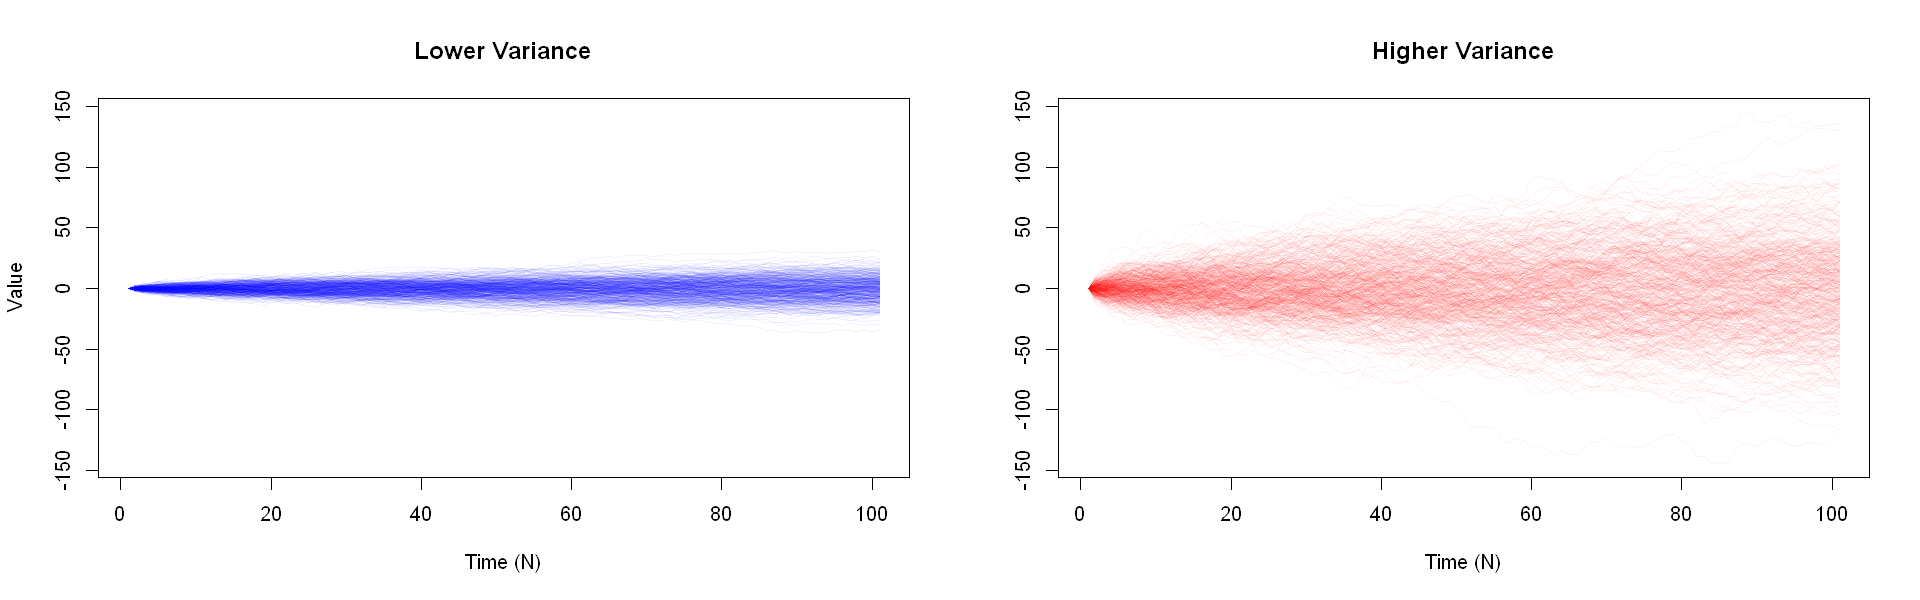

In [65]:
y_limits <- range(high_var_matrix)
par(mfrow = c(1, 2))

# Plot 1: Lower Variance
matplot(low_var_matrix, 
        type = "l",          
        lty = 1,             
        col = rgb(0, 0, 1, 0.05), 
        ylim = y_limits,     
        main = "Lower Variance", 
        xlab = "Time (N)", 
        ylab = "Value")

# Plot 2: Higher Variance
matplot(high_var_matrix, 
        type = "l", 
        lty = 1, 
        col = rgb(1, 0, 0, 0.05), 
        ylim = y_limits,     
        main = "Higher Variance", 
        xlab = "Time (N)", 
        ylab = "")

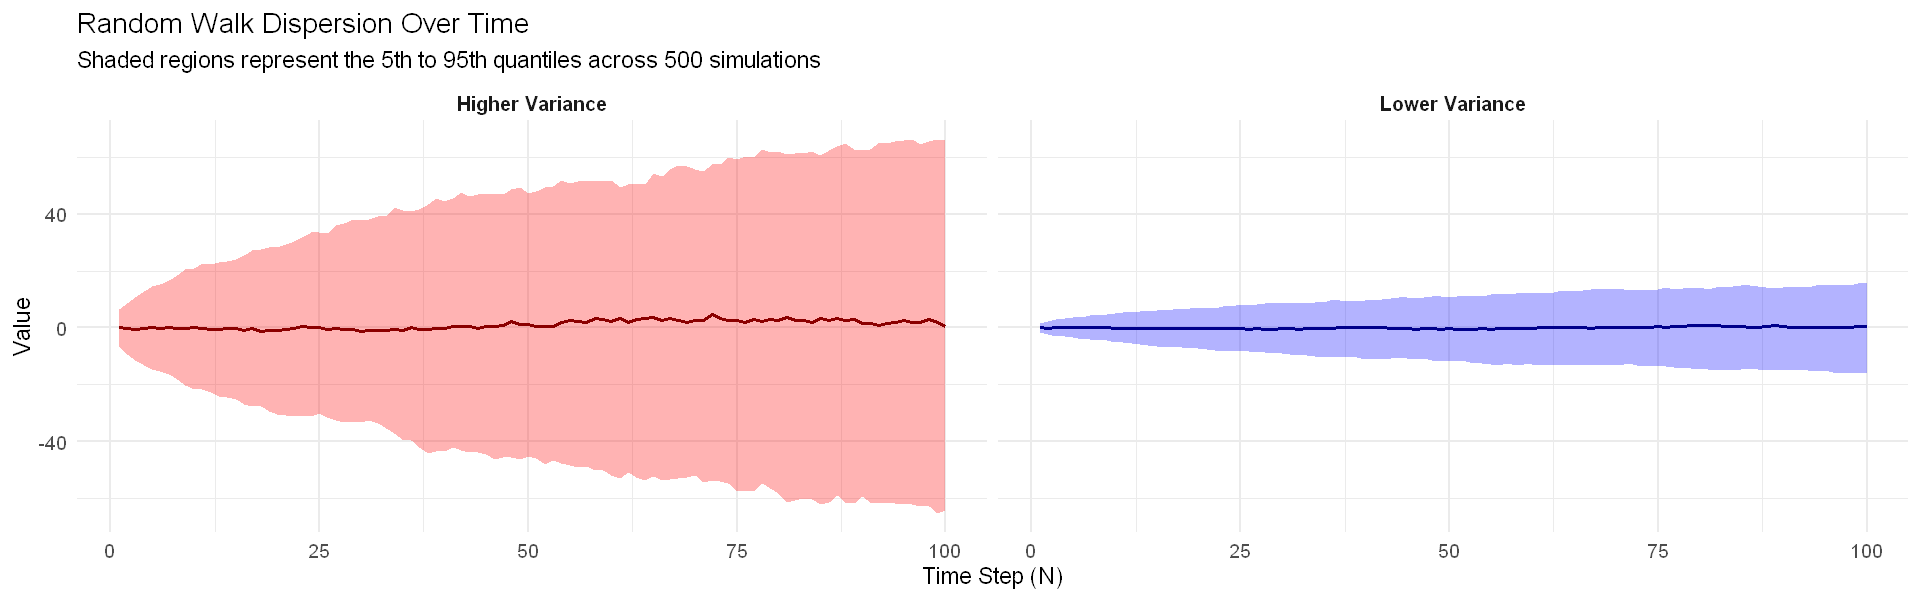

In [66]:
mat_low <- replicate(sims, cumsum(rnorm(N, mean = 0, sd = 1)))
mat_high <- replicate(sims, cumsum(rnorm(N, mean = 0, sd = 4)))

# This function calculates the 5th, 50th (median), and 95th percentiles at each time step
get_dispersion <- function(mat, label) {
  data.frame(
    Time = 1:N,
    Type = label,
    Q_05 = apply(mat, 1, quantile, probs = 0.05), 
    Median = apply(mat, 1, median),               
    Q_95 = apply(mat, 1, quantile, probs = 0.95)  
  )
}

df_low <- get_dispersion(mat_low, "Lower Variance")
df_high <- get_dispersion(mat_high, "Higher Variance")

df_all <- rbind(df_low, df_high)

ggplot(df_all, aes(x = Time)) +
  # Draw the shaded region between the 5th and 95th percentiles
  geom_ribbon(aes(ymin = Q_05, ymax = Q_95, fill = Type), alpha = 0.3) +
  # Draw the median line
  geom_line(aes(y = Median, color = Type), linewidth = 1) +
  
  # facet_wrap puts the two plots side-by-side and automatically locks the y axis
  facet_wrap(~Type) + 
  
  scale_fill_manual(values = c("Lower Variance" = "blue", "Higher Variance" = "red")) +
  scale_color_manual(values = c("Lower Variance" = "darkblue", "Higher Variance" = "darkred")) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Random Walk Dispersion Over Time",
    subtitle = "Shaded regions represent the 5th to 95th quantiles across 500 simulations",
    x = "Time Step (N)",
    y = "Value"
  ) +
  theme(legend.position = "none", 
        strip.text = element_text(face = "bold", size = 12))

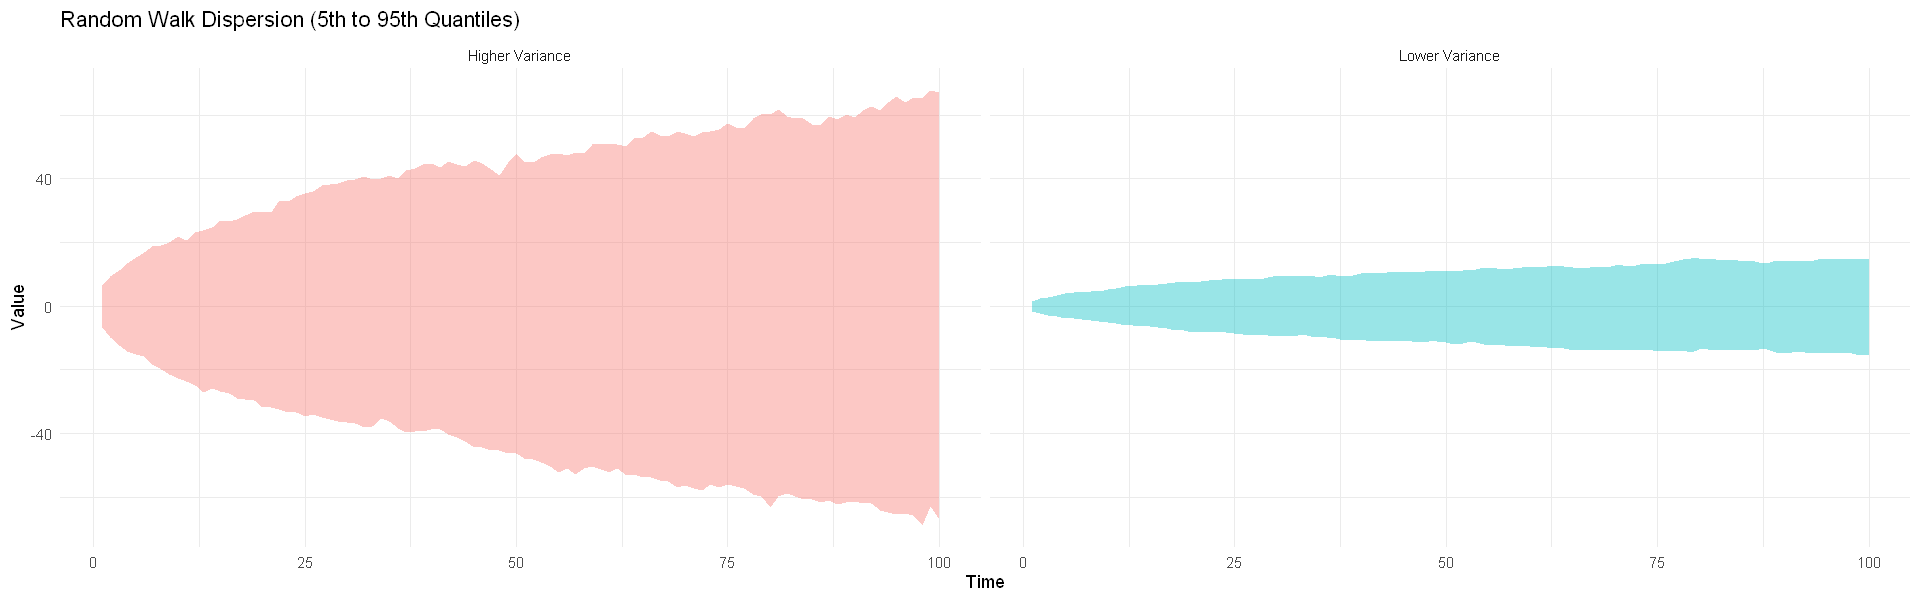

In [67]:
rw_low  <- replicate(500, cumsum(rnorm(100, sd = 1)))
rw_high <- replicate(500, cumsum(rnorm(100, sd = 4)))

# 2. Extract the 5th and 95th quantiles directly into one simple dataframe
df <- data.frame(
  Time = rep(1:100, 2),
  Type = rep(c("Lower Variance", "Higher Variance"), each = 100),
  Q05  = c(apply(rw_low, 1, quantile, 0.05), apply(rw_high, 1, quantile, 0.05)),
  Q95  = c(apply(rw_low, 1, quantile, 0.95), apply(rw_high, 1, quantile, 0.95))
)

# 3. Plot the expanding dispersion side-by-side
ggplot(df, aes(x = Time, ymin = Q05, ymax = Q95, fill = Type)) +
  geom_ribbon(alpha = 0.4) +           
  facet_wrap(~Type) +                  
  theme_minimal() +                    
  labs(title = "Random Walk Dispersion (5th to 95th Quantiles)", y = "Value") +
  theme(legend.position = "none")

#### Disclaimer

***Contributions:***

Daniel Ott - Problem 1 Part 1

Anna Turnerová - Problem 1 Part 2

Samuel Šmíd - Problem 2



***AI usage:***

...